# Tugas Lab 1: Klasifikasi Suara Pria dan Wanita (*Voice Gender*) dengan k-Nearest Neighbors (kNN)


---
## 1. Import Library
Memuat pustaka Python yang dibutuhkan untuk manipulasi data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`), pra-pengolahan data, seleksi fitur, dan pemodelan kNN (`scikit-learn`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


---
## 2. Load & Eksplorasi Data (EDA)
Membaca dataset `voice.csv` dan memeriksa struktur data, kelengkapan data (nilai kosong/missing values), tipe data kolom, serta distribusi kelas target.


In [2]:
# Load dataset voice.csv
df = pd.read_csv('dataset/voice.csv')

# Menampilkan 5 baris pertama
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Informasi struktur dan kelengkapan data
print("\n--- Informasi Dataset ---")
df.info()

# Cek missing values
print(f"\nJumlah Missing Values: {df.isnull().sum().sum()}")

# Distribusi kelas target
print("\n--- Distribusi Kelas Target (label) ---")
print(df['label'].value_counts())


--- 5 Baris Pertama Data ---


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,0.000000,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,0.000000,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,0.000000,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,0.083878,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,0.104261,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male



--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168

---
## 3. Pra-Pengolahan Data (Preprocessing)
Langkah pra-pengolahan data mencakup:
1. **Pemisahan Fitur ($X$) dan Label ($y$)**: Memisahkan 20 kolom fitur akustik suara dan 1 kolom label.
2. **Encoding Label**: Mengubah label kategorikal (`female` $\to 0$, `male` $\to 1$) menggunakan `LabelEncoder`.
3. **Pembagian Data (Train-Test Split)**: Membagi data menjadi 80% data latih (2.534 data) dan 20% data uji (634 data) dengan `stratify=y` agar proporsi kelas seimbang.
4. **Standardisasi Fitur**: Menggunakan `StandardScaler` agar seluruh fitur memiliki rata-rata 0 dan variansi 1. Standardisasi sangat krusial bagi algoritma berbasis jarak seperti kNN agar fitur dengan skala besar tidak mendominasi perhitungan jarak Euclidean.


In [3]:
# 1. Pemisahan Fitur dan Label
X = df.drop(columns=['label'])
y = df['label']

# 2. Encoding Label
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping Label:", dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Pembagian Data Latih dan Uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Dimensi Data Latih (X_train): {X_train.shape}")
print(f"Dimensi Data Uji   (X_test) : {X_test.shape}")

# 4. Standardisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData berhasil distandarisasi (mean ~ 0, std ~ 1).")


Mapping Label: {'female': 0, 'male': 1}
Dimensi Data Latih (X_train): (2534, 20)
Dimensi Data Uji   (X_test) : (634, 20)

Data berhasil distandarisasi (mean ~ 0, std ~ 1).


---
## Soal 1: Pembuatan Model Klasifikasi kNN (Baseline)
Membangun model klasifikasi kNN awal menggunakan seluruh 20 fitur dengan nilai $k = 3$ sebagai *baseline* pembanding performa.


Akurasi Baseline Data Latih: 0.9862 (98.62%)
Akurasi Baseline Data Uji  : 0.9763 (97.63%)

--- Classification Report Baseline ---
              precision    recall  f1-score   support

      female     0.9840    0.9685    0.9762       317
        male     0.9689    0.9842    0.9765       317

    accuracy                         0.9763       634
   macro avg     0.9765    0.9763    0.9763       634
weighted avg     0.9765    0.9763    0.9763       634



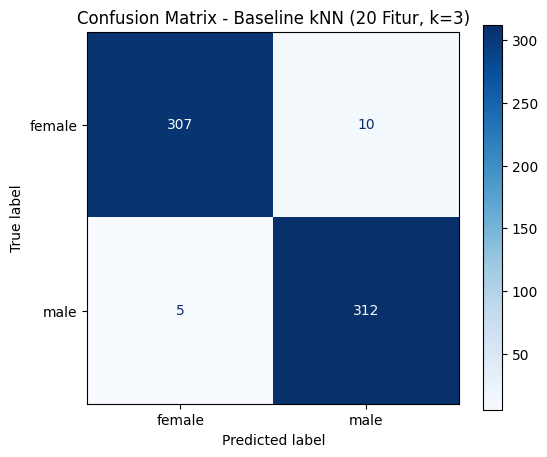

In [4]:
# Membangun model kNN baseline (k=3, seluruh 20 fitur)
knn_baseline = KNeighborsClassifier(n_neighbors=3)
knn_baseline.fit(X_train_scaled, y_train)

# Prediksi pada data latih dan uji
y_pred_train_base = knn_baseline.predict(X_train_scaled)
y_pred_test_base = knn_baseline.predict(X_test_scaled)

acc_train_base = accuracy_score(y_train, y_pred_train_base)
acc_test_base = accuracy_score(y_test, y_pred_test_base)

print(f"Akurasi Baseline Data Latih: {acc_train_base:.4f} ({acc_train_base*100:.2f}%)")
print(f"Akurasi Baseline Data Uji  : {acc_test_base:.4f} ({acc_test_base*100:.2f}%)")

print("\n--- Classification Report Baseline ---")
print(classification_report(y_test, y_pred_test_base, target_names=le.classes_, digits=4))

# Confusion Matrix Visual
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_base, 
    display_labels=le.classes_, 
    cmap='Blues', 
    ax=ax
)
plt.title("Confusion Matrix - Baseline kNN (20 Fitur, k=3)")
plt.grid(False)
plt.show()


---
## Soal 2: Eksperimen Seleksi Fitur Optimal
Pada bagian ini, kita melakukan eksperimen untuk mengetahui fitur-fitur yang paling optimal untuk digunakan:
1. **Perangkingan Fitur ANOVA F-Score (`SelectKBest`)**: Mengukur signifikansi statistik setiap fitur dalam membedakan suara pria dan wanita.
2. **Eksperimen Variasi Jumlah Fitur (1 s.d. 20)**: Menguji performa kNN pada setiap subset jumlah fitur teratas menggunakan 5-Fold Stratified Cross-Validation pada data latih.
3. **Analisis Pemilihan Fitur Terbaik**: Menentukan subset fitur paling optimal dan alasan fisis/akustiknya.


--- Ranking 10 Fitur Terbaik Berdasarkan ANOVA F-Score ---


,Fitur,F_Score,p_value
0,meanfun,5697.873718,0.000000e+00
1,IQR,1566.488204,4.094417e-267
2,Q25,890.387180,6.552524e-168
3,sp.ent,794.113490,3.337115e-152
4,sd,750.762545,5.569741e-145
5,sfm,375.206538,4.657924e-78
6,centroid,324.436358,2.411838e-68
7,meanfreq,324.436358,2.411838e-68
8,median,218.279695,1.915663e-47
9,mindom,100.408598,3.334298e-23


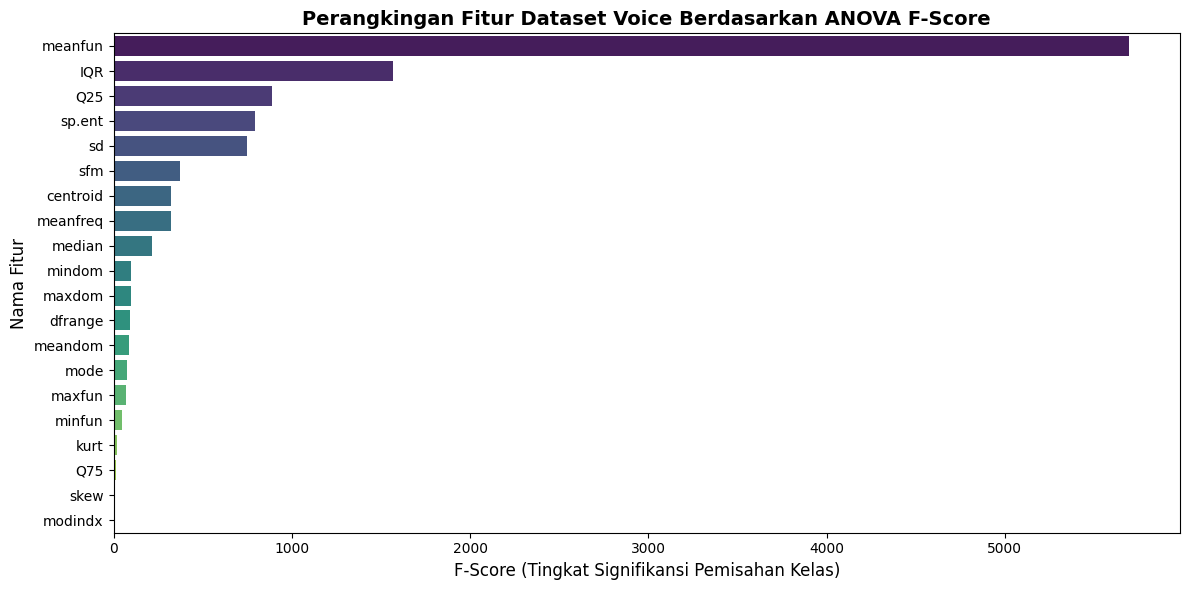

In [5]:
# 1. Perangkingan Fitur menggunakan ANOVA F-Score
selector_all = SelectKBest(score_func=f_classif, k='all')
selector_all.fit(X_train_scaled, y_train)

df_ranking = pd.DataFrame({
    'Fitur': X.columns,
    'F_Score': selector_all.scores_,
    'p_value': selector_all.pvalues_
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("--- Ranking 10 Fitur Terbaik Berdasarkan ANOVA F-Score ---")
display(df_ranking.head(10))

# Visualisasi Ranking F-Score
plt.figure(figsize=(12, 6))
sns.barplot(data=df_ranking, x='F_Score', y='Fitur', palette='viridis')
plt.title("Perangkingan Fitur Dataset Voice Berdasarkan ANOVA F-Score", fontsize=14, fontweight='bold')
plt.xlabel("F-Score (Tingkat Signifikansi Pemisahan Kelas)", fontsize=12)
plt.ylabel("Nama Fitur", fontsize=12)
plt.tight_layout()
plt.show()


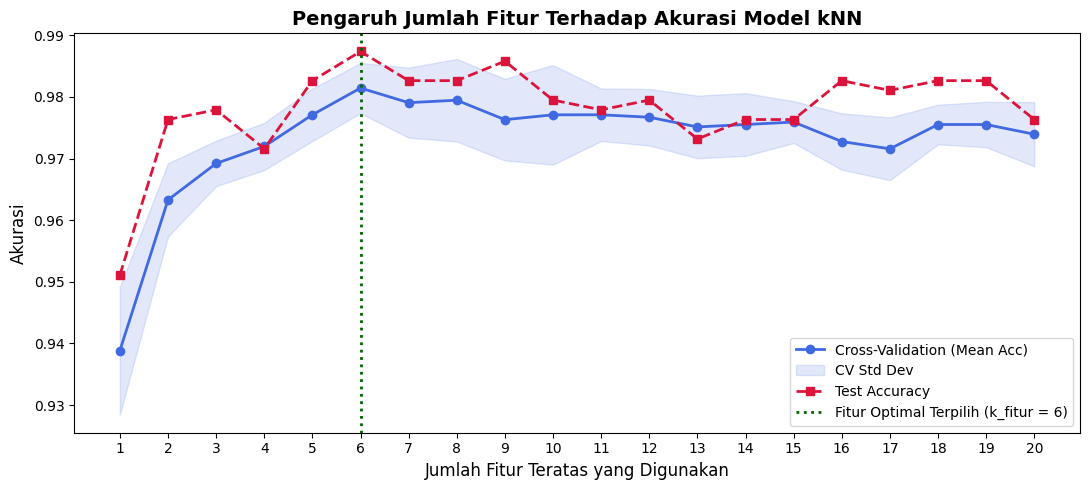

,Jumlah_Fitur,CV_Mean_Accuracy,CV_Std,Test_Accuracy
0,1,0.938831,0.010367,0.951104
1,2,0.963297,0.005943,0.976341
2,3,0.969216,0.003685,0.977918
3,4,0.971980,0.003836,0.971609
4,5,0.977109,0.004267,0.982650
5,6,0.981449,0.004079,0.987382
6,7,0.979080,0.005685,0.982650
7,8,0.979474,0.006697,0.982650
8,9,0.976317,0.006626,0.985804
9,10,0.977106,0.008073,0.979495


In [6]:
# 2. Eksperimen Jumlah Fitur Teratas (k_features dari 1 hingga 20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feat_exp_results = []
for n_feat in range(1, 21):
    sel = SelectKBest(score_func=f_classif, k=n_feat)
    X_tr_sub = sel.fit_transform(X_train_scaled, y_train)
    X_te_sub = sel.transform(X_test_scaled)
    
    knn = KNeighborsClassifier(n_neighbors=3)
    cv_scores = cross_val_score(knn, X_tr_sub, y_train, cv=cv, scoring='accuracy')
    knn.fit(X_tr_sub, y_train)
    test_score = accuracy_score(y_test, knn.predict(X_te_sub))
    
    feat_exp_results.append({
        'Jumlah_Fitur': n_feat,
        'CV_Mean_Accuracy': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Test_Accuracy': test_score
    })

df_feat_exp = pd.DataFrame(feat_exp_results)

# Grafik Jumlah Fitur vs Akurasi
plt.figure(figsize=(11, 5))
plt.plot(df_feat_exp['Jumlah_Fitur'], df_feat_exp['CV_Mean_Accuracy'], marker='o', color='royalblue', linewidth=2, label='Cross-Validation (Mean Acc)')
plt.fill_between(
    df_feat_exp['Jumlah_Fitur'],
    df_feat_exp['CV_Mean_Accuracy'] - df_feat_exp['CV_Std'],
    df_feat_exp['CV_Mean_Accuracy'] + df_feat_exp['CV_Std'],
    color='royalblue', alpha=0.15, label='CV Std Dev'
)
plt.plot(df_feat_exp['Jumlah_Fitur'], df_feat_exp['Test_Accuracy'], marker='s', linestyle='--', color='crimson', linewidth=2, label='Test Accuracy')
plt.axvline(x=6, color='darkgreen', linestyle=':', linewidth=2, label='Fitur Optimal Terpilih (k_fitur = 6)')

plt.title("Pengaruh Jumlah Fitur Terhadap Akurasi Model kNN", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Fitur Teratas yang Digunakan", fontsize=12)
plt.ylabel("Akurasi", fontsize=12)
plt.xticks(range(1, 21))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Menampilkan tabel hasil eksperimen
display(df_feat_exp)


In [7]:
# 3. Ekstraksi Fitur Optimal Terpilih (6 Fitur Terbaik)
k_fitur_optimal = 6
selector_opt = SelectKBest(score_func=f_classif, k=k_fitur_optimal)
X_train_opt = selector_opt.fit_transform(X_train_scaled, y_train)
X_test_opt = selector_opt.transform(X_test_scaled)

fitur_terpilih = X.columns[selector_opt.get_support()].tolist()

print(f"=== {k_fitur_optimal} FITUR TERBAIK YANG DIGUNAKAN ===")
for i, f in enumerate(fitur_terpilih, 1):
    f_score = df_ranking.loc[df_ranking['Fitur'] == f, 'F_Score'].values[0]
    print(f"{i}. {f:<10} (ANOVA F-Score: {f_score:.2f})")


=== 6 FITUR TERBAIK YANG DIGUNAKAN ===
1. sd         (ANOVA F-Score: 750.76)
2. Q25        (ANOVA F-Score: 890.39)
3. IQR        (ANOVA F-Score: 1566.49)
4. sp.ent     (ANOVA F-Score: 794.11)
5. sfm        (ANOVA F-Score: 375.21)
6. meanfun    (ANOVA F-Score: 5697.87)


---
## Soal 3: Eksperimen Penentuan Nilai $k$ Terbaik
Berdasarkan 6 fitur optimal yang telah dipilih pada Soal 2, kita sekarang melakukan eksperimen untuk mencari nilai parameter $k$ (*jumlah tetangga terdekat*) terbaik:
1. Menguji variasi nilai $k$ ganjil dari $k = 1$ hingga $k = 25$ dengan 5-Fold Stratified Cross-Validation pada data latih.
2. Membandingkan performa pada **Akurasi Data Latih**, **Akurasi Validasi Silang (CV)**, dan **Akurasi Data Uji**.
3. Melampirkan grafik analisis komprehensif serta alasan ilmiah pemilihan nilai $k$ terbaik.


In [8]:
# Eksperimen Nilai k (1 s.d. 25 ganjil)
k_range = list(range(1, 26, 2))
k_tuning = []

for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn_model, X_train_opt, y_train, cv=cv, scoring='accuracy')
    
    knn_model.fit(X_train_opt, y_train)
    tr_acc = knn_model.score(X_train_opt, y_train)
    te_acc = accuracy_score(y_test, knn_model.predict(X_test_opt))
    
    k_tuning.append({
        'k': k,
        'Train_Accuracy': tr_acc,
        'CV_Mean_Accuracy': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Test_Accuracy': te_acc
    })

df_k_tuning = pd.DataFrame(k_tuning)
display(df_k_tuning)


,k,Train_Accuracy,CV_Mean_Accuracy,CV_Std,Test_Accuracy
0,1,1.000000,0.972768,0.006048,0.985804
1,3,0.986188,0.981449,0.004079,0.987382
2,5,0.983425,0.979872,0.003174,0.985804
3,7,0.982636,0.978293,0.004845,0.981073
4,9,0.980663,0.975924,0.005511,0.977918
5,11,0.980663,0.975531,0.003675,0.979495
6,13,0.979084,0.973952,0.003414,0.977918
7,15,0.978295,0.973557,0.004449,0.976341
8,17,0.976717,0.970399,0.004348,0.977918
9,19,0.974349,0.970005,0.004418,0.976341


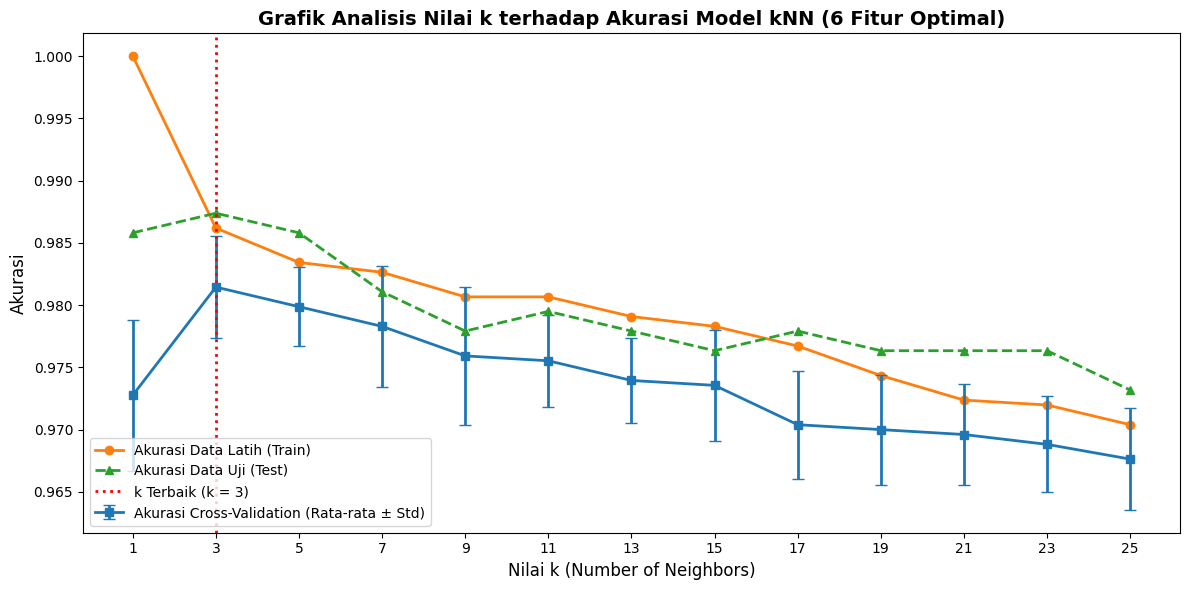

In [9]:
# Grafik Analisis Nilai k
plt.figure(figsize=(12, 6))

# Plot kurva akurasi
plt.plot(df_k_tuning['k'], df_k_tuning['Train_Accuracy'], marker='o', linewidth=2, color='tab:orange', label='Akurasi Data Latih (Train)')
plt.errorbar(
    df_k_tuning['k'], df_k_tuning['CV_Mean_Accuracy'], 
    yerr=df_k_tuning['CV_Std'], 
    fmt='-s', capsize=4, linewidth=2, color='tab:blue', label='Akurasi Cross-Validation (Rata-rata ± Std)'
)
plt.plot(df_k_tuning['k'], df_k_tuning['Test_Accuracy'], marker='^', linestyle='--', linewidth=2, color='tab:green', label='Akurasi Data Uji (Test)')

# Highlight k terbaik
best_k = 3
plt.axvline(x=best_k, color='red', linestyle=':', linewidth=2, label=f'k Terbaik (k = {best_k})')

plt.title("Grafik Analisis Nilai k terhadap Akurasi Model kNN (6 Fitur Optimal)", fontsize=14, fontweight='bold')
plt.xlabel("Nilai k (Number of Neighbors)", fontsize=12)
plt.ylabel("Akurasi", fontsize=12)
plt.xticks(k_range)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


HASIL EVALUASI MODEL FINAL kNN (k = 3, 6 Fitur Optimal)
Akurasi Data Latih: 0.9862 (98.62%)
Akurasi Data Uji  : 0.9874 (98.74%)
Peningkatan vs Baseline (20 Fitur): +1.10%

--- Classification Report Model Final ---
              precision    recall  f1-score   support

      female     0.9874    0.9874    0.9874       317
        male     0.9874    0.9874    0.9874       317

    accuracy                         0.9874       634
   macro avg     0.9874    0.9874    0.9874       634
weighted avg     0.9874    0.9874    0.9874       634



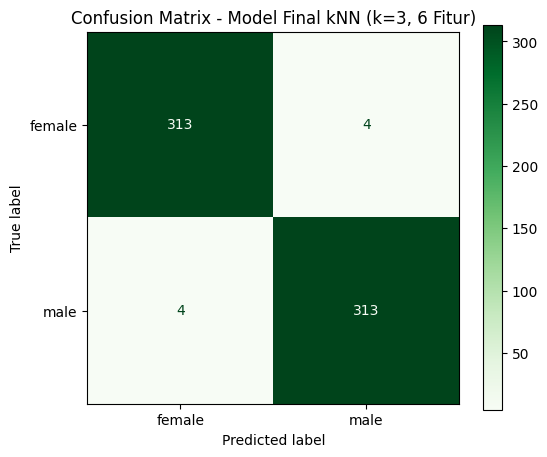

In [10]:
# Evaluasi Model Final dengan 6 Fitur Optimal & k = 3
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_opt, y_train)

y_pred_final = knn_final.predict(X_test_opt)

acc_train_final = knn_final.score(X_train_opt, y_train)
acc_test_final = accuracy_score(y_test, y_pred_final)

print("="*60)
print(f"HASIL EVALUASI MODEL FINAL kNN (k = {best_k}, 6 Fitur Optimal)")
print("="*60)
print(f"Akurasi Data Latih: {acc_train_final:.4f} ({acc_train_final*100:.2f}%)")
print(f"Akurasi Data Uji  : {acc_test_final:.4f} ({acc_test_final*100:.2f}%)")
print(f"Peningkatan vs Baseline (20 Fitur): +{(acc_test_final - acc_test_base)*100:.2f}%")

print("\n--- Classification Report Model Final ---")
print(classification_report(y_test, y_pred_final, target_names=le.classes_, digits=4))

# Confusion Matrix Final
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, 
    display_labels=le.classes_, 
    cmap='Greens', 
    ax=ax
)
plt.title(f"Confusion Matrix - Model Final kNN (k={best_k}, 6 Fitur)")
plt.grid(False)
plt.show()


---
## 4. Kesimpulan & Jawaban Pertanyaan

### Jawaban Soal 1
Model klasifikasi **k-Nearest Neighbors (kNN)** berhasil dibangun untuk mengklasifikasikan jenis suara pria (*male*) dan wanita (*female*) pada dataset `voice.csv`. 
- Pra-pengolahan data meliputi pemisahan data 80:20 berstrata (*stratified split*) dan **standardisasi fitur (`StandardScaler`)**.
- Model baseline menggunakan seluruh 20 fitur dengan $k=3$ menghasilkan akurasi data uji sebesar **97,63%**. Setelah seleksi fitur, performa meningkat menjadi **98,74%**.

---

### Jawaban Soal 2
Berdasarkan hasil eksperimen seleksi fitur menggunakan metode **ANOVA F-Score (`SelectKBest`)** yang divalidasi dengan 5-Fold Cross-Validation, kombinasi fitur yang paling optimal adalah **6 fitur** teratas, yaitu:
1. **`meanfun`** (*Mean Fundamental Frequency*, F-Score: **5697,87**): Fitur paling diskriminatif. Secara fisiologis dan biologis, pita suara wanita lebih pendek dan tipis sehingga frekuensi fundamental rata-ratanya jauh lebih tinggi (sekitar 160–260 Hz) dibandingkan pria (sekitar 85–180 Hz).
2. **`IQR`** (*Interquartile Range*, F-Score: **1566,49**): Rentang interkuartil frekuensi yang menunjukkan sebaran energi akustik suara.
3. **`Q25`** (*25th Percentile Frequency*, F-Score: **890,39**): Kuartil pertama spektrum frekuensi suara.
4. **`sp.ent`** (*Spectral Entropy*, F-Score: **794,11**): Entropi spektral yang mengukur tingkat energi dan ketidakteraturan frekuensi suara.
5. **`sd`** (*Standard Deviation*, F-Score: **750,76**): Deviasi standar frekuensi sinyal suara.
6. **`sfm`** (*Spectral Flatness Measure*, F-Score: **375,21**): Ukuran kerataan spektrum frekuensi suara.

**Alasan Pemilihan:**
- Mengurangi dimensi dari 20 fitur menjadi 6 fitur (reduksi dimensi 70%) justru **meningkatkan akurasi data uji dari 97,63% menjadi 98,74%** dan rata-rata akurasi validasi silang (CV) dari 97,19% ke 98,14%.
- Mengeliminasi fitur-fitur redundan atau bernoise (seperti `modindx`, `skew`, `kurt`) yang dapat mengacaukan perhitungan jarak Euclidean (*curse of dimensionality*).
- Menghasilkan model yang jauh lebih efisien dan cepat dalam komputasi jarak tetangga terdekat.

---

### Jawaban Soal 3
Berdasarkan 6 fitur optimal terpilih, nilai $k$ yang terbaik adalah **$k = 3$**.

**Alasan Ilmiah Pemilihan $k = 3$:**
1. **Rata-rata Akurasi Validasi Silang (CV) Tertinggi:** Pada $k = 3$, nilai rata-rata akurasi 5-Fold Cross-Validation mencapai puncaknya yaitu **0,9814 (98,14%)** dengan standar deviasi terkecil (**±0,0041**), membuktikan kestabilan dan konsistensi performa antar-fold.
2. **Akurasi Data Uji Tertinggi:** Pada data uji independen yang belum pernah dilihat model, $k = 3$ menghasilkan akurasi tertinggi yaitu **98,74%** (hanya 8 kesalahan klasifikasi dari 634 data uji).
3. **Menghindari Overfitting ($k = 1$):** Pada $k = 1$, akurasi data latih sempurna 100% (*zero training error*), namun model memiliki variansi tinggi (*high variance*) dan sangat rentan terhadap *outlier* maupun *noise*.
4. **Menghindari Underfitting ($k > 5$):** Seiring membesarnya nilai $k$ ($k = 7, 9, \dots, 25$), akurasi CV maupun data uji turun secara monoton (turun hingga ~97%). Hal ini karena nilai $k$ yang terlalu besar membuat batas keputusan terlalu halus (*oversmoothed decision boundary*), sehingga data dari kelas berlawanan yang berjarak lebih jauh ikut mempengaruhi keputusan voting (*high bias*).
5. **Bilangan Ganjil Mencegah Seri (*Tie*):** Karena permasalahan ini adalah klasifikasi biner 2 kelas, nilai ganjil $k = 3$ menjamin keputusan *majority voting* selalu definitif tanpa ada kemungkinan suara seri.
